# 1_data_prep_Li
streamlined notebook showing the current routine of grid loading and trimming before we save in the form used for training and testing pitchforks

- duplicated for different grids
- upstream of sandbox files used to test new data augmentations and make plots - do not mess around with grids here!

In [33]:
#misc
import pandas as pd
import numpy as np
import time
import os

#plotting
import matplotlib.pyplot as plt

## load in the grid:

In [28]:
df_full = pd.concat([pd.read_hdf("/home/oxs235/datastorage/repos_data/ojscutt/mesa_ajl/data/grid2p5a/grid.h5", key=f"m{0.8 + i*0.02:.2f}") for i in range(21)], ignore_index=True)

#check column headers we have to work with
print("check columns: " + str([column for column in df_full.columns.values]))

check columns: ['index', 'dirname', 'filename', 'model_number', 'evol_stage', 'initial_mass', 'initial_Yinit', 'initial_Zinit', 'initial_feh', 'initial_MLT', 'initial_fov', 'star_mass', 'star_age', 'ms_age', 'frac_age', 'effective_T', 'luminosity', 'radius', 'log_g', 'surface_h1', 'surface_he4', 'surface_Z', 'star_feh', 'center_h1', 'center_he4', 'log_center_T', 'log_center_Rho', 'he_core_mass', 'delta_nu', 'delta_Pg', 'nu_max', 'acoustic_cutoff', 'nu_0_1', 'nu_0_2', 'nu_0_3', 'nu_0_4', 'nu_0_5', 'nu_0_6', 'nu_0_7', 'nu_0_8', 'nu_0_9', 'nu_0_10', 'nu_0_11', 'nu_0_12', 'nu_0_13', 'nu_0_14', 'nu_0_15', 'nu_0_16', 'nu_0_17', 'nu_0_18', 'nu_0_19', 'nu_0_20', 'nu_0_21', 'nu_0_22', 'nu_0_23', 'nu_0_24', 'nu_0_25', 'nu_0_26', 'nu_0_27', 'nu_0_28', 'nu_0_29', 'nu_0_30', 'nu_0_31', 'nu_0_32', 'nu_0_33', 'nu_0_34', 'nu_0_35', 'nu_0_36', 'nu_0_37', 'nu_0_38', 'nu_0_39', 'nu_0_40']


## data prep:
cuts and scalings typically informed by messing around in grid_sandbox files

### pre prep plots
show some tracks and distributions for grid points before any cuts are made

/tmp/ipykernel_3085139/1423002420.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  plot_points = pd.concat([plot_points,track])


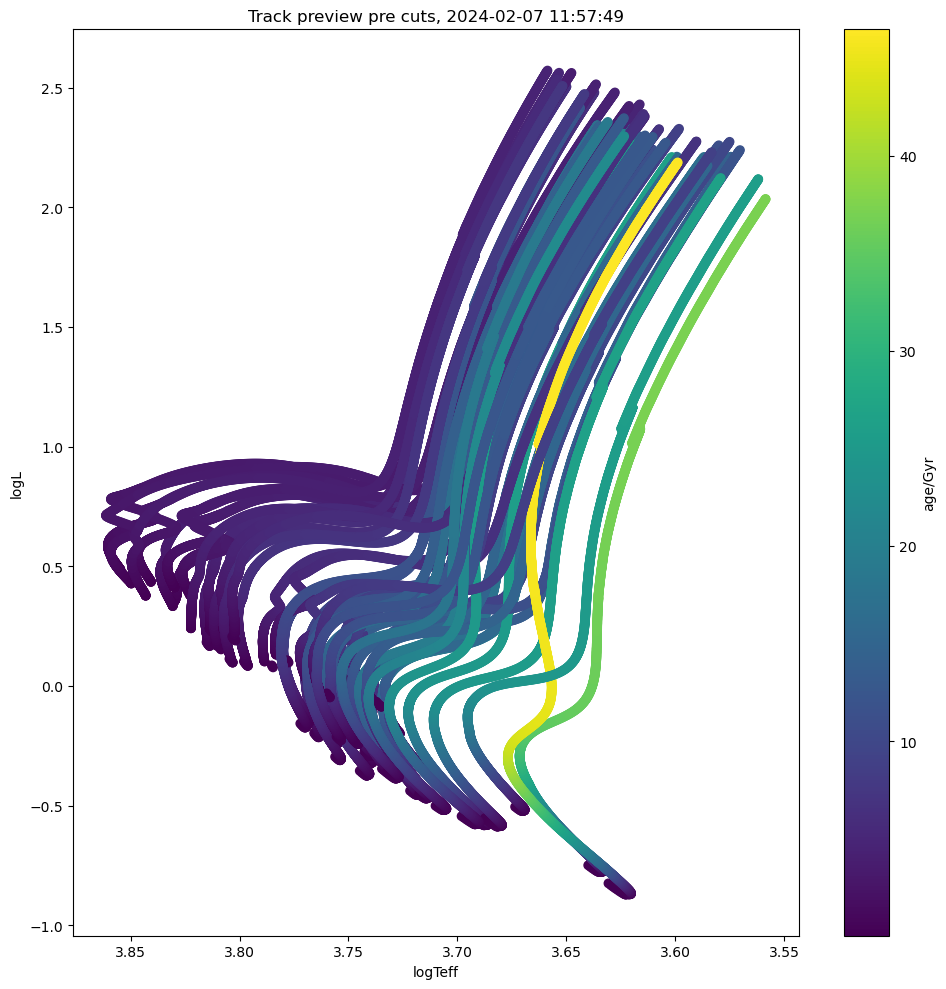

In [40]:
n = 50 #number of tracks
seed = 42

#select unique tracks
dirname_df = pd.DataFrame(df_full['dirname'].unique(), columns=["dirname"])
dirname_sample = dirname_df.sample(n=n, random_state=seed)

plot_points = pd.DataFrame(columns=df_full.columns)

#sample tracks according to n
for dirname in dirname_sample["dirname"]:
    track = df_full[df_full["dirname"] == dirname]
    plot_points = pd.concat([plot_points,track])

#plotting
fig, ax = plt.subplots(figsize=(10,10))

plt.scatter(np.log10(plot_points["effective_T"]), np.log10(plot_points["luminosity"]), c=plot_points["star_age"])
cbar = plt.colorbar()
cbar.ax.set_ylabel("age/Gyr")
ax.set_ylabel("logL")
ax.set_xlabel("logTeff")
ax.set_title("Track preview pre cuts, "+ time.strftime("%Y-%m-%d %H:%M:%S"))
ax.invert_xaxis()
fig.tight_layout()

#optional, save fig
figdir = "figs/data_prep_Li/tracks/tracks_without_cuts_" + time.strftime("%Y%m%d-%H%M%S")
plt.savefig(figdir + ".png", transparent="false", facecolor="white", bbox_inches="tight")
plt.show()

## post prep plots
show some tracks post prep - this is the dataset we'll use for training!

/tmp/ipykernel_3085139/3794744698.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  plot_points = pd.concat([plot_points,track])


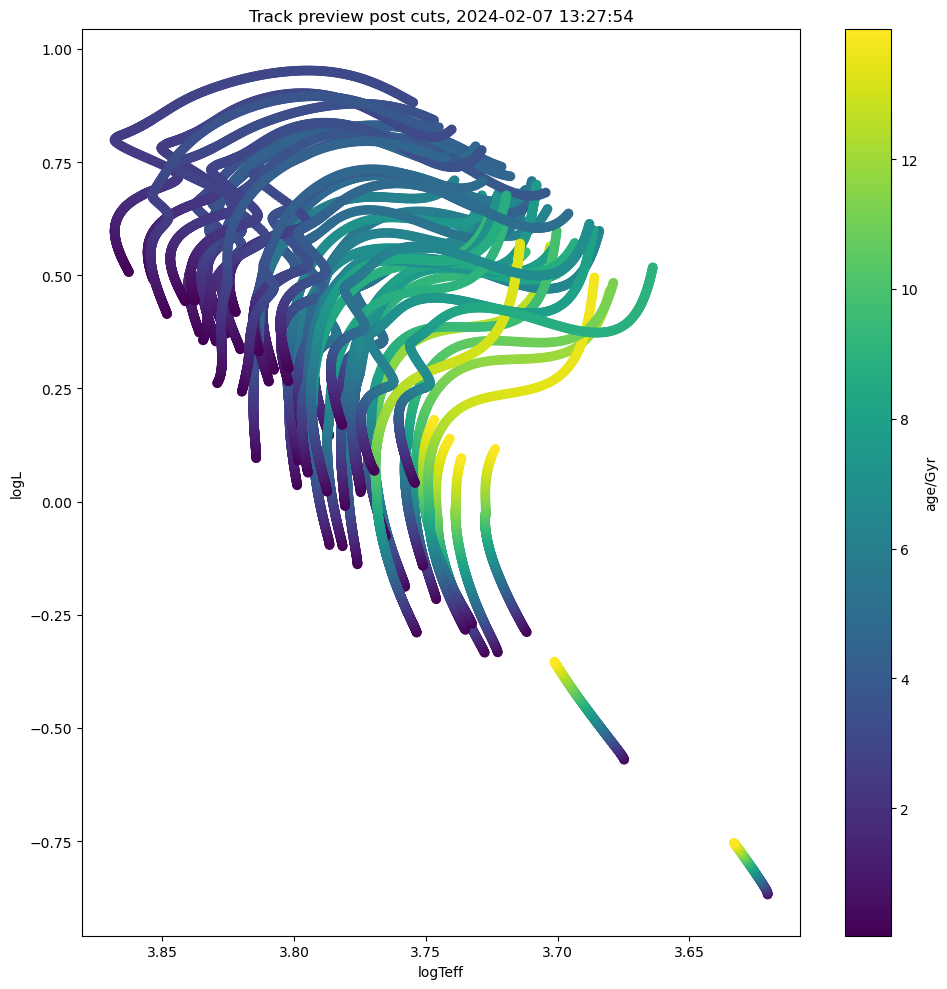

In [43]:
# load in grid and make cuts
df_full = pd.concat([pd.read_hdf("/home/oxs235/datastorage/repos_data/ojscutt/mesa_ajl/data/grid2p5a/grid.h5", key=f"m{0.8 + i*0.02:.2f}") for i in range(21)], ignore_index=True)
df = df_full[df_full["log_g"] >= 3.6]
df = df[df["star_age"] <= 14]
df = df[df["frac_age"] >= 0.015]

inputs = ['initial_mass', 'initial_Zinit', 'initial_Yinit', 'initial_MLT', 'star_age']
outputs = ['radius', 'luminosity','effective_T', 'star_feh'] + [f'nu_0_{i+1}' for i in range(3,40)]

df = df.loc[(df[[f'nu_0_{i+1}' for i in range(3,40)]] != 0).all(axis=1)]

df.dropna(inplace=True)

df["log_star_age"] = np.log10(df["star_age"])
df["log_radius"] = np.log10(df["radius"])
df["log_luminosity"] = np.log10(df["luminosity"])
df["log_effective_T"] = np.log10(df["effective_T"])

df[[f'log_nu_0_{i+1}' for i in range(3,40)]] = np.log10(df[[f'nu_0_{i+1}' for i in range(3,40)]])

n = 50 #number of tracks
seed = 42

dirname_df = pd.DataFrame(df['dirname'].unique(), columns=["dirname"])
dirname_sample = df.sample(n=n, random_state=seed)

plot_points = pd.DataFrame(columns=df.columns)

for dirname in dirname_sample["dirname"]:
    track = df[df["dirname"] == dirname]
    plot_points = pd.concat([plot_points,track])

fig, ax = plt.subplots(figsize=(10,10))

plt.scatter(np.log10(plot_points["effective_T"]), np.log10(plot_points["luminosity"]), c=plot_points["star_age"])
cbar = plt.colorbar()
cbar.ax.set_ylabel("age/Gyr")
ax.set_ylabel("logL")
ax.set_xlabel("logTeff")
ax.set_title("Track preview post cuts, "+ time.strftime("%Y-%m-%d %H:%M:%S"))
ax.invert_xaxis()
fig.tight_layout()

figdir = "figs/data_prep_Li/tracks/tracks_with_cuts_" + time.strftime("%Y%m%d-%H%M%S")
plt.savefig(figdir + ".png", transparent="false", facecolor="white", bbox_inches="tight")
plt.show()


## save prepared grid:

In [46]:
"""
save as hdf
"""
df_full = pd.concat([pd.read_hdf("/home/oxs235/datastorage/repos_data/ojscutt/mesa_ajl/data/grid2p5a/grid.h5", key=f"m{0.8 + i*0.02:.2f}") for i in range(21)], ignore_index=True)
df = df_full[df_full["log_g"] >= 3.6]
df = df[df["star_age"] <= 14]
df = df[df["frac_age"] >= 0.015]

inputs = ['initial_mass', 'initial_Zinit', 'initial_Yinit', 'initial_MLT', 'star_age']
outputs = ['radius', 'luminosity','effective_T', 'star_feh'] + [f'nu_0_{i+1}' for i in range(3,40)]

df = df.loc[(df[[f'nu_0_{i+1}' for i in range(3,40)]] != 0).all(axis=1)]

cols = inputs + outputs

df = df[cols]

df.dropna(inplace=True)

df["log_star_age"] = np.log10(df["star_age"])
df["log_radius"] = np.log10(df["radius"])
df["log_luminosity"] = np.log10(df["luminosity"])
df["log_effective_T"] = np.log10(df["effective_T"])

df[[f'log_nu_0_{i+1}' for i in range(3,40)]] = np.log10(df[[f'nu_0_{i+1}' for i in range(3,40)]])

print(len(df))

df.to_hdf("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/df_all_log.h5", key="df")

2448681
